**Importing libraries:**

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

**Loading dataset:**

In [3]:
batch_size = 128
transform = transforms.Compose([
    transforms.ToTensor()
])
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 338kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.14MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.21MB/s]


MNIST contains images of handwritten digits and each image has 28*28 pixel size.

ToTensor() converts pixel values from 0–255 to 0–1

Data is loaded in mini-batches for efficient training

**Variational Autoencoder Model:**

In [4]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        return mu + epsilon * std

    def decode(self, z):
        h = self.relu(self.fc2(z))
        return self.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

Encoder:

Each input image is mapped to a Gaussian distribution in latent space, not a fixed point.

This makes the model probabilistic rather than deterministic.

Latent space:

Instead of learning a single compressed vector, the model learns a distribution describing the input data.

Reparameterization:

It rewrites sampling in a differentiable form.

This allows the model to:

1. sample latent vectors

2. still update weights through gradient descent

Decoder:

The decoder tries to reconstruct the original handwritten digit image from the compressed latent representation.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

**Optimizer:**

In [5]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Adam optimizer updates model weights using gradients. It is widely used because:

1. adapts learning rate

2. converges faster than standard gradient descent

**VAE Loss Function:**

In [6]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(
        recon_x, x, reduction='sum'
    )
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl_loss, recon_loss, kl_loss

Loss has two components:

1. Reconstruction loss:

It measures how close the reconstructed image is to the original image. If high then model is not reconstructing images correctly. If decreases then, model is learning.

2. KL Divergence Loss
This ensures:

a. structured latent space

b. smooth transitions between data points

c. ability to generate new digits

**Training Loop:**

In [7]:
epochs = 10
for epoch in range(epochs):
    total_loss = 0
    for data, _ in train_loader:
        data = data.view(-1, 784).to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss, recon_loss, kl_loss = vae_loss(
            recon_batch, data, mu, logvar
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Total Loss: {total_loss:.2f}")
    print(f"Reconstruction Loss: {recon_loss:.2f}")
    print(f"KL Divergence Loss: {kl_loss:.2f}")

Epoch 1/10
Total Loss: 9836422.19
Reconstruction Loss: 10595.24
KL Divergence Loss: 1999.87
Epoch 2/10
Total Loss: 7258960.46
Reconstruction Loss: 8573.14
KL Divergence Loss: 2322.05
Epoch 3/10
Total Loss: 6863444.36
Reconstruction Loss: 8481.40
KL Divergence Loss: 2381.84
Epoch 4/10
Total Loss: 6689351.77
Reconstruction Loss: 8335.96
KL Divergence Loss: 2420.11
Epoch 5/10
Total Loss: 6585943.43
Reconstruction Loss: 7856.76
KL Divergence Loss: 2265.24
Epoch 6/10
Total Loss: 6509630.00
Reconstruction Loss: 7935.02
KL Divergence Loss: 2396.32
Epoch 7/10
Total Loss: 6465818.08
Reconstruction Loss: 8198.69
KL Divergence Loss: 2517.40
Epoch 8/10
Total Loss: 6423809.52
Reconstruction Loss: 8152.01
KL Divergence Loss: 2377.32
Epoch 9/10
Total Loss: 6390538.60
Reconstruction Loss: 7801.71
KL Divergence Loss: 2437.85
Epoch 10/10
Total Loss: 6367525.33
Reconstruction Loss: 7913.68
KL Divergence Loss: 2403.99


In each training step
1. Images are flatten
2. Forward pass
3. Sample latent vector
4. Decode
5. Loss computation
6. Backpropogation

During training the model learns to:

1. compress digit images into a low-dimensional latent space

2. reconstruct them accurately

3. maintain a normal latent distribution

In [9]:
import matplotlib.pyplot as plt

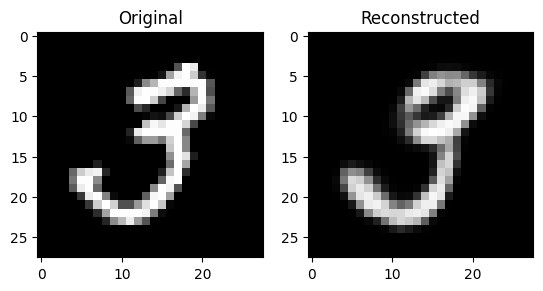

In [10]:
data, _ = next(iter(train_loader))
data = data.view(-1,784)
with torch.no_grad():
    recon, _, _ = model(data)

original = data[0].view(28,28)
reconstructed = recon[0].view(28,28)

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(original, cmap="gray")
plt.subplot(1,2,2)
plt.title("Reconstructed")
plt.imshow(reconstructed, cmap="gray")
plt.show()

The reconstructed image closely resembles the original MNIST digit, indicating that the Variational Autoencoder successfully learned a compressed latent representation of the data.